In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Adding 0.5 to distortion to plot as RGB image",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="plenoptic's methods have mostly been tested on",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Clipping input data to the valid range",
)

:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`Eigendistortions.ipynb`**!

:::


(eigendistortion-nb)=
# Eigendistortions

**In this tutorial we will cover:**

- Theory behind eigendistortions.
- How to use the {class}`Eigendistortion <plenoptic.synthesize.eigendistortion.Eigendistortion>` object.
- Computing eigendistortions using a simple input and linear model.
- Computing extremal eigendistortions for different layers of ResNet18.

## Introduction

How can we assess whether a model sees like we do? One way is to test whether they "notice" image distortions the same way as us. For a model, a noticeable distortion would be an image perturbation that elicits a change in its response. If our goal is to create models with human-like vision, then an image distortion that is (not) noticeable to a human should also (not) be noticeable to our models. Eigendistortions provide a framework with which to compare models to human visual perception of distortions.

This method was first discussed in [Berardino, A., Laparra, V., Ballé, J. and Simoncelli, E., 2017. Eigen-distortions of hierarchical representations. In Advances in neural information processing systems (pp. 3530-3539)](https://www.cns.nyu.edu/pub/lcv/berardino17c-final.pdf), and additional details can also be found on the [Lab for Computational Vision website](https://www.cns.nyu.edu/~lcv/eigendistortions/).

See the [last section of this notebook](eigendistortion-math-details) for more mathematical detail.

In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
# this notebook runs just about as fast with GPU and CPU
DEVICE = torch.device("cpu")


import plenoptic as po
from plenoptic.synthesize.eigendistortion import Eigendistortion

# so that relative sizes of axes created by po.imshow and others look right
plt.rcParams["figure.dpi"] = 72

# this notebook uses torchvision, which is an optional dependency.
# if this fails, install torchvision in your plenoptic environment
# and restart the notebook kernel.
try:
    from torchvision import models
    from torchvision.models import feature_extraction
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "optional dependency torchvision not found!"
        " please install it in your plenoptic environment "
        "and restart the notebook kernel"
    )

## Example 1: Linear model, small 1D input "image"


### 1.1) Creating the model

The fundamental goal of computing eigendistortions is to understand how small changes (distortions) in inputs affect model outputs. Any model can be thought of as a black box mapping an input to an output, $f(x): x \in \mathbb{R}^n \mapsto y \in \mathbb{R}^m$, i.e. a function takes as input an n-dimensional vector $x$ and outputs an m-dimensional vector $y$.


The simplest model that achieves this is linear, $y = f(x) = Mx$, where $M\in \mathbb{R}^{m\times n}$.

In this linear case, the Jacobian is fixed $J= \frac{\partial f}{\partial x}=M$ for all possible inputs $x$. Can we *synthesize* a distortion $\epsilon$ such that $f(x+\epsilon)$ is maximally/minimally perturbed from the original $f(x)$? Yes! This would amount to finding the first and last eigenvectors of the Fisher information matrix, i.e. $J^TJ v = \lambda v$.

We'll be working with the {class}`Eigendistortion <plenoptic.synthesize.eigendistortion.Eigendistortion>` object and its method, {func}`synthesize <plenoptic.synthesize.eigendistortion.Eigendistortion.synthesize>`.

Let's make a linear model and compute eigendistortions for a given input.

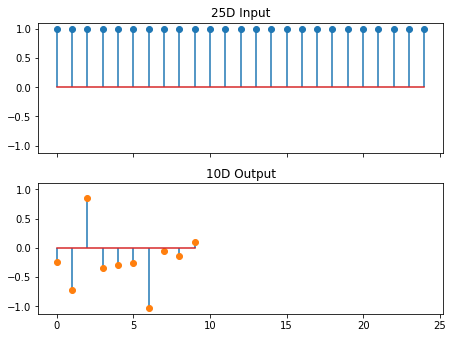

In [3]:
class LinearModel(nn.Module):
    """The simplest model we can make.
    Its Jacobian should be the weight matrix of M, and the eigenvectors of the
    Fisher matrix are therefore the eigenvectors of M.T @ M"""

    def __init__(self, n, m):
        super().__init__()
        torch.manual_seed(0)
        self.M = nn.Linear(n, m, bias=False)

    def forward(self, x):
        y = self.M(x)  # this computes y = x @ M.T
        return y


# input vector dim (can you predict what the eigenvec/vals would be when n<m or n=m?
# Feel free to try!)
n = 25
m = 10  # output vector dim

mdl_linear = LinearModel(n, m)
mdl_linear.eval()
po.tools.remove_grad(mdl_linear)

x0 = torch.ones(n)
y0 = mdl_linear(x0)

fig, ax = plt.subplots(2, 1, sharex="all", sharey="all")
ax[0].stem(x0)
ax[0].set(title=f"{n:d}D Input")

ax[1].stem(y0.detach(), markerfmt="C1o")
ax[1].set(title=f"{m:d}D Output")
fig.tight_layout()

### 1.2 - Synthesizing eigendistortions of linear model

To compute the eigendistortions of this model, we can instantiate an {class}`Eigendistortion <plenoptic.synthesize.eigendistortion.Eigendistortion>` object with an input tensor and a valid PyTorch model with a `forward` method. After that, we simply call the method {func}`synthesize <plenoptic.synthesize.eigendistortion.Eigendistortion.synthesize>`, choosing the appropriate synthesis method. Normally our input has thousands of entries, but our input in this case is small (only n=25 entries), so we can compute the full $m \times n$ Jacobian, and all the eigenvectors of the $n \times n$ Fisher matrix, $F=J^TJ$. The {func}`synthesize <plenoptic.synthesize.eigendistortion.Eigendistortion.synthesize>` method does this for us and stores the outputs (``eigendistortions, eigenvalues, eigenindex``) of the synthesis.

In [4]:
# instantiate Eigendistortion object using an input and model
eig_jac = Eigendistortion(
    x0, mdl_linear
)
# compute the entire Jacobian exactly
eig_jac.synthesize(method="exact")

### 1.3 - Comparing our synthesis to ground-truth

The Jacobian is in general a rectangular (not necessarily square) matrix $J\in \mathbb{R}^{m\times n}$. Since this is a linear model, let's check if the computed Jacobian (stored as the {attr}`jacobian <plenoptic.synthesize.eigendistortion.Eigendistortion.jacobian>` attribute in the {class}`Eigendistortion <plenoptic.synthesize.eigendistortion.Eigendistortion>` object) matches the weight matrix $M$.

Since the eigendistortions are each 1D (vectors) in this example, we can display them all as an image where each column is an eigendistortion, each pixel is an entry of the eigendistortion, and the intensity is proportional to its value.

Jacobian == weight matrix M?: True


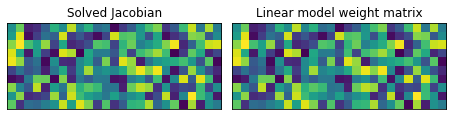

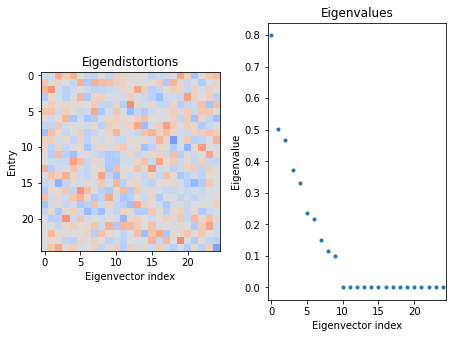

In [5]:
fig, ax = plt.subplots(1, 2, sharex="all", sharey="all")
ax[0].imshow(eig_jac.jacobian)
ax[1].imshow(
    mdl_linear.M.weight.data,
    vmin=eig_jac.jacobian.min(),
    vmax=eig_jac.jacobian.max(),
)
ax[0].set(xticks=[], yticks=[], title="Solved Jacobian")
ax[1].set(title="Linear model weight matrix")
fig.tight_layout()

print(
    "Jacobian == weight matrix M?:",
    eig_jac.jacobian.allclose(mdl_linear.M.weight.data),
)

# Eigenvectors (aka eigendistortions) and associated eigenvectors are found in the
# distortions dict attribute
fig, ax = plt.subplots(1, 2, sharex="all")
ax[0].imshow(eig_jac.eigendistortions, vmin=-1, vmax=1, cmap="coolwarm")
ax[0].set(title="Eigendistortions", xlabel="Eigenvector index", ylabel="Entry")
ax[1].plot(eig_jac.eigenvalues, ".")
ax[1].set(title="Eigenvalues", xlabel="Eigenvector index", ylabel="Eigenvalue")
fig.tight_layout()

### 1.4 - What do these eigendistortions _mean_?

The first eigenvector (with the largest eigenvalue) is the direction in which we can distort our input $x$ and change the response of the model the _most_, i.e. its most noticeable distortion. For the last eigenvector, since its associated eigenvalue is 0, then _no change in response occurs_ when we distort the input in that direction, i.e. $f(x+\epsilon)=f(x)$. So this distortion would be _imperceptible_ to the model.

In most cases, our input would be much larger. An $n\times n$ image has $n^2$ entries, meaning the Fisher matrix is $n^2 \times n^2$, and therefore $n^2$ possible eigendistortions -- certainly too large to store in memory. We need to instead resort to numerical methods to compute the eigendistortions. To do this, we can just set our synthesis `method='power'` to estimate the first eigenvector (most noticeable distortion) and last eigenvector (least noticeable distortion) for the image.

In [6]:
eig_pow = Eigendistortion(x0, mdl_linear)
eig_pow.synthesize(method="power", max_iter=1000)
eigdist_pow = eig_pow.eigendistortions

print(f"Indices of computed eigenvectors: {eig_pow.eigenindex}\n")


Top k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Bottom k=1 eigendists computed | Stop criterion 1.00E-07 reached.
Indices of computed eigenvectors: tensor([ 0, 24])



Now let's compare the eigendistortions we got from these two methods:

Are the first eigendistortions the same? True
Are the last eigendistortions the same? False


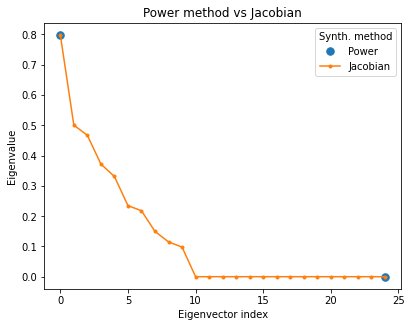

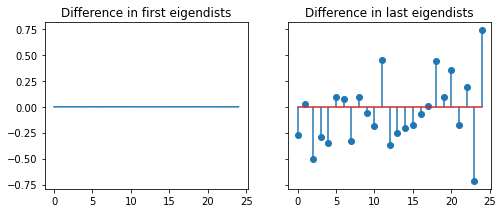

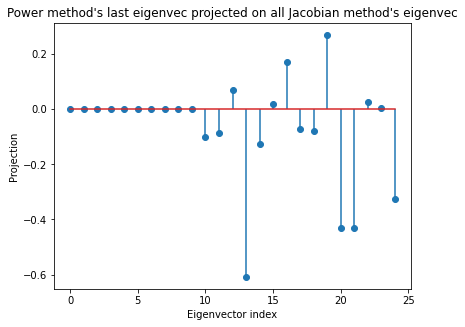

In [7]:
eigdist_jac = eig_jac.eigendistortions
fig, ax = plt.subplots(1, 1)
ax.plot(eig_pow.eigenindex, eig_pow.eigenvalues, ".", markersize=15, label="Power")
ax.plot(eig_jac.eigenvalues, ".-", label="Jacobian")
ax.set(
    title="Power method vs Jacobian",
    xlabel="Eigenvector index",
    ylabel="Eigenvalue",
)
ax.legend(title="Synth. method")

fig, ax = plt.subplots(1, 2, sharex="all", sharey="all", figsize=(8, 3))
ax[0].plot(eigdist_pow[0] - eigdist_jac[0])
ax[0].set(title="Difference in first eigendists")

ax[1].stem(eigdist_pow[-1] - eigdist_jac[-1])
ax[1].set(title="Difference in last eigendists")

fig, ax = plt.subplots(1, 1)
ax.stem(eigdist_jac @ eigdist_pow[-1])
ax.set(
    title="Power method's last eigenvec projected on all Jacobian method's eigenvec",
    xlabel="Eigenvector index",
    ylabel="Projection",
)

print(
    "Are the first eigendistortions the same?",
    eigdist_pow[0].allclose(eigdist_jac[0], atol=1e-3),
)
print(
    "Are the last eigendistortions the same?",
    eigdist_pow[-1].allclose(eigdist_jac[-1], atol=1e-3),
)

# find eigendistortions of Jacobian-method whose eigenvalues are zero
ind_zero = eig_jac.eigenvalues.isclose(torch.zeros(1), atol=1e-4)

The power method's first eigendistortion matches the ground-truth first eigendistortion obtained via the Jacobian solve. And while the last eigendistortions don't match, the last power method eigendistortion lies in the span of all the eigendistortions whose eigenvalues are zero. Each of these eigendistortions whose eigenvalues are zero are equivalent. Any distortion of $x$ in the span of these eigendistortions would result in _no change_ in the model output, and would therefore be imperceptible to the model.

(fisher-locally-adaptive)=
### 1.5 - The Fisher information matrix is locally adaptive
Different inputs should in general have different sets of eigendistortions -- a noticible distortion in one image would not necessarily be noticeable in a different image. The only case where they should be the same regardless of input is when the model is fully linear, as in this simple example. So let's check if the Jacobian at a different input still equals the weight matrix $M$.

In [8]:
# generate some random input
x1 = torch.randn_like(x0)

eig_jac2 = Eigendistortion(x1, model=mdl_linear)
eig_jac2.synthesize(
    method="exact"
)

# since the model is linear, the Jacobian should be the exact same as before
print(
    f"Does the jacobian at x1 still equal the model weight matrix?"
    f" {eig_jac2.jacobian.allclose(mdl_linear.M.weight.data)}"
)

Does the jacobian at x1 still equal the model weight matrix? True


## Example 2: Which layer of ResNet is a better model of human visual distortion perception?

Now that we understand what eigendistortions are and how the {class}`Eigendistortion <plenoptic.synthesize.eigendistortion.Eigendistortion>` class works, let's compute them real images using a more complex model: ResNet18. The response vector $y$ doesn't necessarily have to be the output of the last layer of the model; we can also compute Eigendistortions for intermediate model layers too. Let's synthesize distortions for an image using different layers of ResNet18 to see which layer produces extremal eigendistortions that align more with human perception.


### 2.1 - Load an example an image

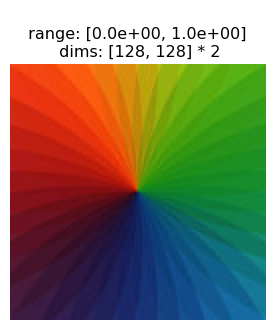

In [9]:
# this will be the img_height and width of the input, you can change this to
# accommodate your machine
n = 128
img = po.data.color_wheel().to(DEVICE)
# center crop the image to nxn
img = po.tools.center_crop(img, n)
po.imshow(img, as_rgb=True, zoom=2);

### 2.2 - Instantiate models and Eigendistortion objects
Let's make a wrapper class that can return the nth layer output of ResNet18. We're going to use this to compare eigendistortions synthesized using different layers of ResNet18 as models for distortion perception.

In [10]:
class TorchVision(torch.nn.Module):
    def __init__(self, model, return_node: str):
        super().__init__()
        self.extractor = feature_extraction.create_feature_extractor(
            model, return_nodes=[return_node]
        )
        self.model = model
        self.return_node = return_node

    def forward(self, x):
        return self.extractor(x)[self.return_node]

# different potential models of human visual perception of distortions
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1, progress=False)
resnet = resnet.to(DEVICE)
resnet18_a = TorchVision(resnet, "maxpool")
po.tools.remove_grad(resnet18_a)
resnet18_a.eval()
resnet18_b = TorchVision(resnet, "layer2")
po.tools.remove_grad(resnet18_b)
resnet18_b.eval()

ed_resneta = Eigendistortion(img, resnet18_a)
ed_resnetb = Eigendistortion(img, resnet18_b)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jenkins/workspace/neurorse_plenoptic_PR-358@2/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


### 2.3 - Synthesizing distortions
The input dimensionality in this example is huge compared to our linear model example -- it is $(\textrm{n_chan} \times \textrm{img_height} \times \textrm{img_width})^2$, meaning the Fisher matrix is too massive to compute exactly. We must turn to iterative methods. Let's synthesize the extremal eigendistortions for this picture of Einstein using the different layers of ResNet as defined above.

In [11]:
# Bump up n_steps if you wish
ed_resneta.synthesize(method="power", max_iter=400)
ed_resnetb.synthesize(method="power", max_iter=400)

Top k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

Top k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

### 2.4 - Visualizing eigendistortions

Let's display the eigendistortions.

`plenoptic` includes a {func}`display_eigendistortion_all <plenoptic.synthesize.eigendistortion.display_eigendistortion_all>` function to visualize multiple eigendistortiosn together. Here, we show the original image on the bottom left, with the synthesized maximal eigendistortion in the top middle, and some constant $\alpha$ times the eigendistortion added to the image in the bottom middle. The rightmost column has a similar layout, but displays the minimal eigendistortion. Let's display the eigendistortions for the maxpool layer (pretty early in the model):

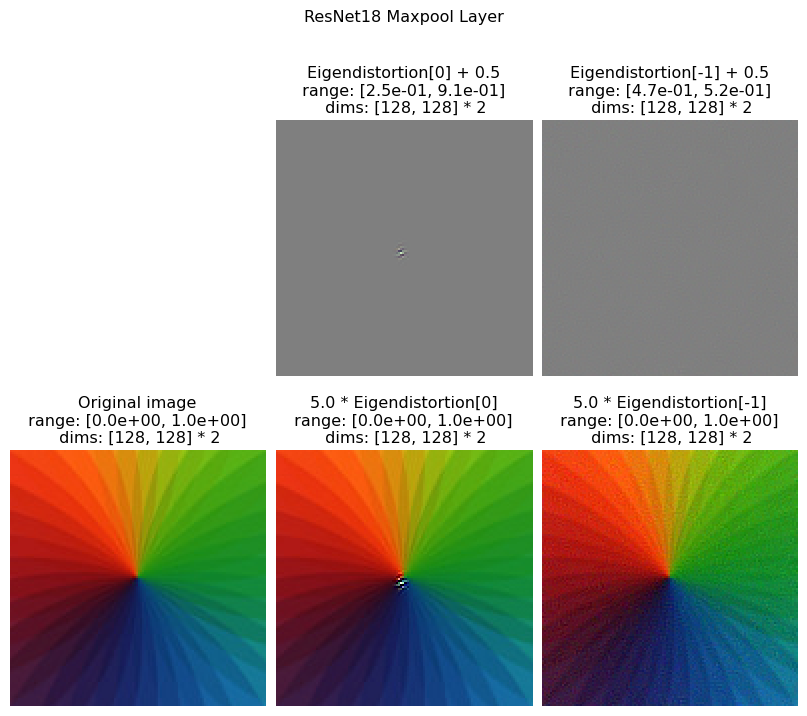

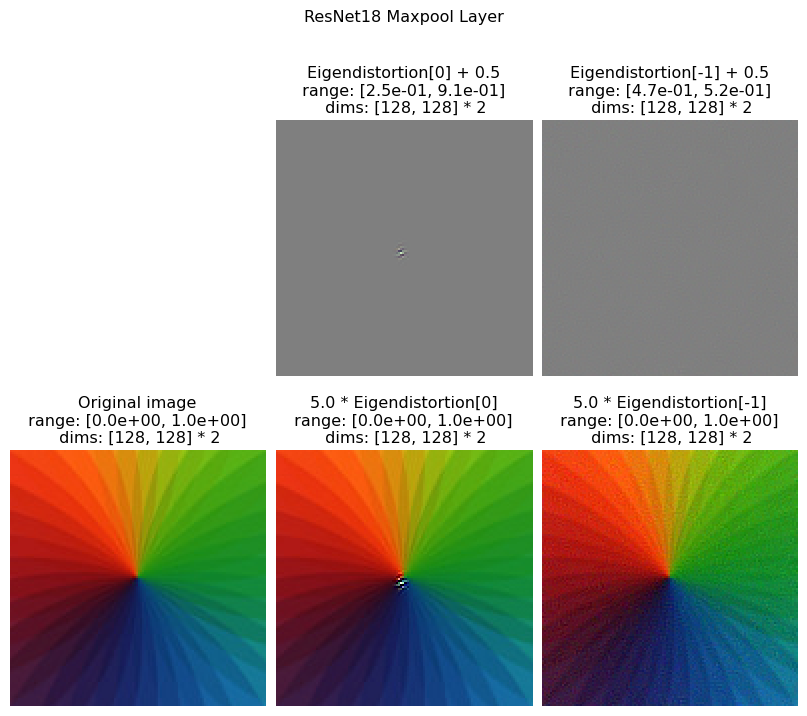

In [12]:
po.synth.eigendistortion.display_eigendistortion_all(ed_resneta, [0, -1], as_rgb=True, suptitle="ResNet18 Maxpool Layer", zoom=2)

And the eigendistortions for layer 2 (about halfway through the model):

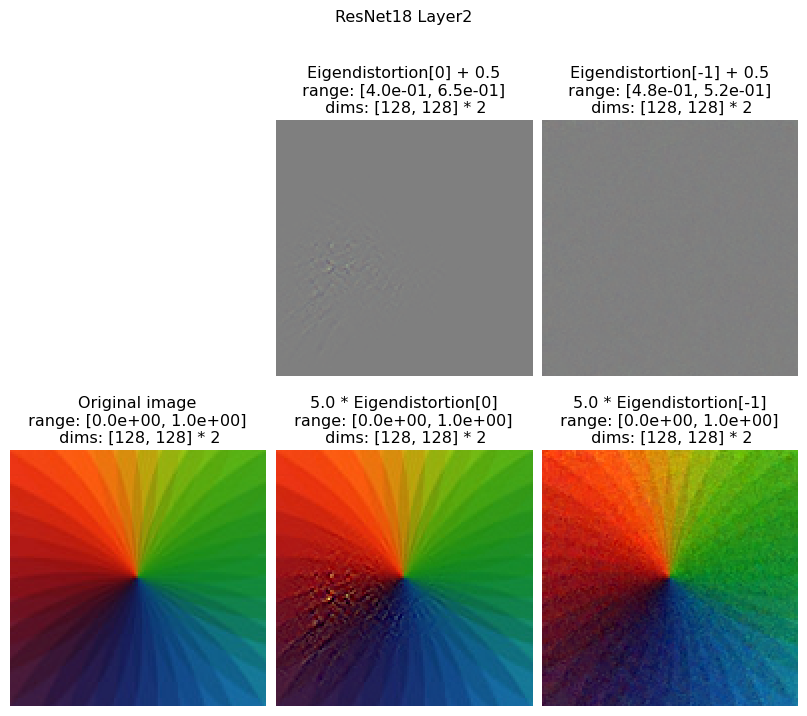

In [13]:
po.synth.eigendistortion.display_eigendistortion_all(ed_resnetb, [0, -1], as_rgb=True, suptitle="ResNet18 Layer2", zoom=2);

### 2.5 - Which synthesized extremal eigendistortions better characterize human perception?

Let's compare eigendistortions within a model first. One thing we immediately notice is that the first eigendistortion (labeled `maxdist`) is indeed more noticeable than `mindist`. `maxdist` is localized to a single portion of the image, and has lower, more prominent spatial frequency content than `mindist`. `mindist` looks more like high frequency noise distributed across the image.

But how do the distortions compare between models -- which model better characterizes human visual perception of distortions? The only way to truly this is to run an experiment and ask human observers which distortions are most/least noticeable to them. The best model should produce a maximally noticeable distortion that is more noticeable than other models' maximally noticeable distortions, and its minimally noticeable distortion should be less noticeable than other models' minimally noticeable distortions.

See [Berardino et al. 2017](https://www.cns.nyu.edu/pub/lcv/berardino17c-final.pdf) for more details.

### 2.6 - Synthesizing distortions for other images

Remember the Fisher matrix is locally adaptive, meaning that a different image should have a different set of eigendistortions. Let's finish off this notebook with another set of extremal eigendistortions for these two ResNet18 layers on a different image.

In [14]:
img = po.data.curie().to(DEVICE)

# center crop the image to nxn
img = po.tools.center_crop(img, n)
# because this is a grayscale image but ResNet expects a color image,
# need to duplicate along the color dimension
img3 = torch.repeat_interleave(img, 3, dim=1)

ed_resneta = Eigendistortion(img3, resnet18_a)
ed_resnetb = Eigendistortion(img3, resnet18_b)

ed_resneta.synthesize(method="power", max_iter=400)
ed_resnetb.synthesize(method="power", max_iter=400)

Top k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

Top k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/400 [00:00<?, ?it/s]

Unlike our [previous example](fisher-locally-adaptive), eigendistortions for either ResNet layer will differ depending upon the image they start with. We can see that below, where the Curie-based eigendistortions are different from the color wheel-based ones we examined earlier. First, the eigendistortions for the maxpool layer (pretty early in the model):

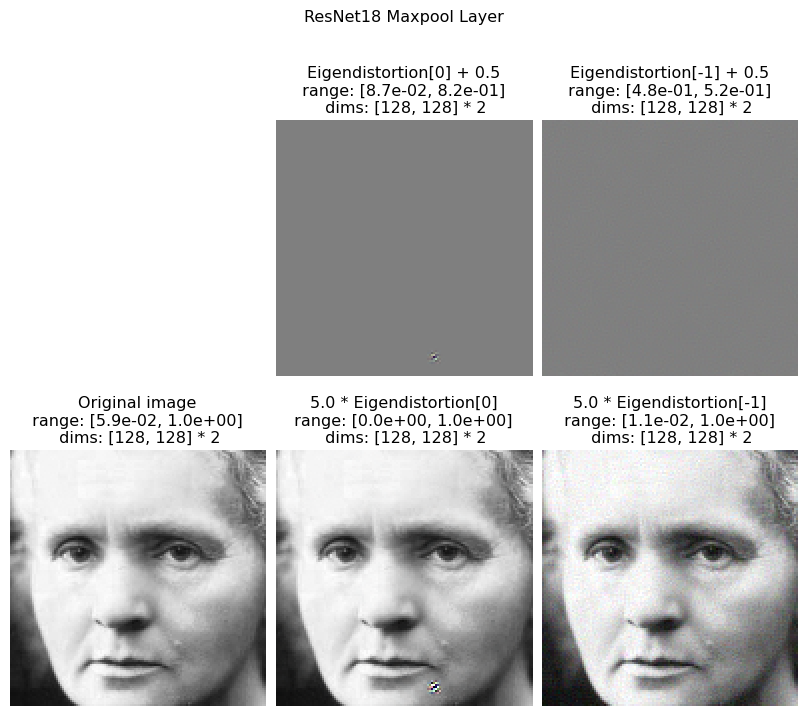

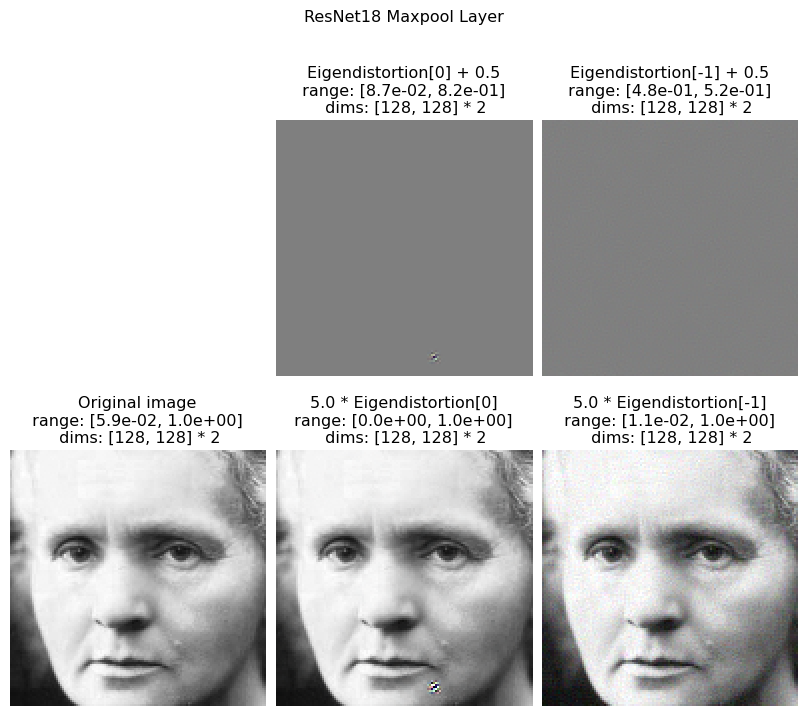

In [15]:
po.synth.eigendistortion.display_eigendistortion_all(ed_resneta, [0, -1], as_rgb=True, suptitle="ResNet18 Maxpool Layer", zoom=2)

And the eigendistortions for layer 2 (about halfway through the model):

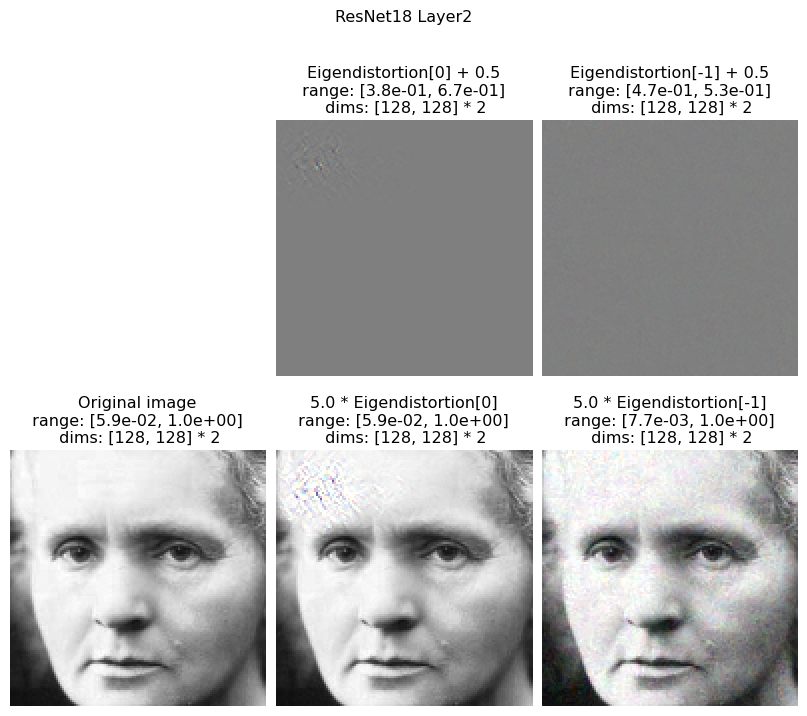

In [16]:
po.synth.eigendistortion.display_eigendistortion_all(ed_resnetb, [0, -1], as_rgb=True, suptitle="ResNet18 Layer2", zoom=2);

(eigendistortion-math-details)=
## Appendix: More mathematical detail

If we have a model that takes an N-dimensional input and outputs an M-dimensional response, then its Jacobian,
$J=\frac{\partial f}{\partial x}$, is an $M\times N$ matrix of partial derivatives that tells us how much a change in
each entry of the input would change each entry of the output. With the assumption of additive Gaussian noise in the
output space Fisher Information Matrix, $F$, is a symmetric positive semi-definite, $N\times N$ matrix computed using
the Jacobian, $F=J^TJ$. If you are familiar with linear algebra, you might notice that  the eigenvectors of $F$ are
the right singular vectors of the Jacobian. Thus, an eigendecomposition $F=V\Lambda V$ yields directions of the
_input space_ (vectors in $V$) along which changes in the _output space_ are rank-ordered by entries in diagonal
matrix $\Lambda$.

Given some input image $x_0$, an **eigendistortion** is an additive perturbation, $\epsilon$, in the _input domain_
that changes the response in a model's _output domain_ of interest (e.g. an intermediate layer of a neural net, the
output of a nonlinear model, etc.).
These perturbations are named _eigendistortions_ because they push $x_0$ along eigenvectors of the Fisher Information Matrix.
So we expect distortions $x_0$ along the direction of the eigenvector with the maximum eigenvalue will change the
representation the _most_, and distortions along the eigenvector with the minimum eigenvalue will change the
representation  the _least_. (And pushing along intermediate eigenvectors will change the representation by an
intermediate amount.)